# 08 — Extended Baselines (80/20 Design)

Tests three ideas not covered in 03b/04b:
1. **Logistic Regression (L1 and L2)** evaluated on MIMIC — simpler models may generalise better cross-domain
2. **Feature-selective RF** — drops BP/INR features that are 84% missing in eICU training, addressing root cause #1 from gap analysis
3. **Ensemble** — probability blend of RF-calibrated + LR-L1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, os, pickle, json
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.calibration     import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics         import (roc_auc_score, average_precision_score,
                                     roc_curve, precision_recall_curve)

SEED = 42
np.random.seed(SEED)

BASE      = '/content/drive/MyDrive/AI in Medicine/data/output_data/preprocessed'
MODEL_DIR = '/content/drive/MyDrive/AI in Medicine/models'
EXT8_DIR  = f'{MODEL_DIR}/extended_80'
os.makedirs(EXT8_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 1. Load 80/20 Data and Reference Model

In [ ]:
X_train = pd.read_csv(f'{BASE}/X_train_80.csv')
y_train = pd.read_csv(f'{BASE}/y_train_80.csv').squeeze()
X_val   = pd.read_csv(f'{BASE}/X_val_80.csv')
y_val   = pd.read_csv(f'{BASE}/y_val_80.csv').squeeze()
X_mimic = pd.read_csv(f'{BASE}/X_mimic_80.csv')
y_mimic = pd.read_csv(f'{BASE}/y_mimic_80.csv').squeeze()

with open(f'{MODEL_DIR}/model_params_80.json') as f:
    params = json.load(f)
log_odds_shift = params['log_odds_shift']
MIMIC_THR      = params['mimic_threshold']
RF_CAL_THR     = params['rf_cal_threshold']
best_rf_params = params['rf_best_params']

with open(f'{MODEL_DIR}/rf_calibrated_80.pkl', 'rb') as f:
    rf_cal = pickle.load(f)

# ── helpers ──────────────────────────────────────────────────────────────────
def apply_ls(probs, shift=log_odds_shift):
    lo = np.log(np.clip(probs, 1e-9, 1-1e-9) / (1 - np.clip(probs, 1e-9, 1-1e-9)))
    return 1 / (1 + np.exp(-(lo + shift)))

def youden_thr(y, probs):
    fpr, tpr, thrs = roc_curve(y, probs)
    return float(thrs[np.argmax(tpr - fpr)])

def ls_thr(thr_raw, shift=log_odds_shift):
    """Shift a val Youden threshold to MIMIC space via the same log-odds transform."""
    lo = np.log(np.clip(thr_raw, 1e-9, 1-1e-9) / (1 - np.clip(thr_raw, 1e-9, 1-1e-9)))
    return float(1 / (1 + np.exp(-(lo + shift))))

def evaluate(y_true, probs, thr, label=''):
    auc  = roc_auc_score(y_true, probs)
    pr   = average_precision_score(y_true, probs)
    pred = (probs >= thr).astype(int)
    sens = float((pred[y_true==1] == 1).mean())
    spec = float((pred[y_true==0] == 0).mean())
    print(f'{label:<40}  AUC={auc:.3f}  PR={pr:.3f}  Sens={sens:.3f}  Spec={spec:.3f}')
    return {'auc': auc, 'pr': pr, 'sens': sens, 'spec': spec}

# reference
p_rf_val        = rf_cal.predict_proba(X_val)[:, 1]
p_rf_mimic_raw  = rf_cal.predict_proba(X_mimic)[:, 1]
p_rf_mimic_ls   = apply_ls(p_rf_mimic_raw)

print(f'X_train {X_train.shape}  X_val {X_val.shape}  X_mimic {X_mimic.shape}')
print('\nReference RF calibrated (80/20 baseline):')
ref_val   = evaluate(y_val,   p_rf_val,      RF_CAL_THR, '  Val')
ref_mimic = evaluate(y_mimic, p_rf_mimic_ls, MIMIC_THR,  '  MIMIC (label shift)')

X_train (2016, 81)  X_val (504, 81)  X_mimic (136, 81)

Reference RF calibrated (80/20 baseline):
  Val                                     AUC=0.826  PR=0.432  Sens=0.640  Spec=0.904
  MIMIC (label shift)                     AUC=0.734  PR=0.642  Sens=0.674  Spec=0.678


## 2. Logistic Regression on MIMIC

LR was not evaluated on MIMIC in notebook 03b. In 80/20 design, LR val AUC (0.839) exceeded RF calibrated (0.826). Simpler models with L1 sparsity may generalise better cross-domain by avoiding eICU-specific interaction patterns.

In [ ]:
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ── L2 ───────────────────────────────────────────────────────────────────────
lr_l2 = LogisticRegression(C=0.1, class_weight='balanced', max_iter=2000, random_state=SEED)
lr_l2.fit(X_train, y_train)
lr_l2_cv = cross_val_score(lr_l2, X_train, y_train, cv=cv5, scoring='roc_auc')
print(f'LR-L2  5-fold CV AUC: {lr_l2_cv.mean():.3f} ± {lr_l2_cv.std():.3f}')

p_lr_l2_val       = lr_l2.predict_proba(X_val)[:, 1]
p_lr_l2_mimic_ls  = apply_ls(lr_l2.predict_proba(X_mimic)[:, 1])
lr_l2_val_thr     = youden_thr(y_val, p_lr_l2_val)
lr_l2_mimic_thr   = ls_thr(lr_l2_val_thr)

print('\nLR-L2 (C=0.1, balanced):')
lr_l2_val_res   = evaluate(y_val,   p_lr_l2_val,      lr_l2_val_thr,   '  Val')
lr_l2_mimic_res = evaluate(y_mimic, p_lr_l2_mimic_ls, lr_l2_mimic_thr, '  MIMIC (label shift)')

# ── L1 ───────────────────────────────────────────────────────────────────────
lr_l1 = LogisticRegression(C=0.1, penalty='l1', solver='liblinear',
                            class_weight='balanced', max_iter=2000, random_state=SEED)
lr_l1.fit(X_train, y_train)
n_nonzero = int((lr_l1.coef_ != 0).sum())
lr_l1_cv  = cross_val_score(lr_l1, X_train, y_train, cv=cv5, scoring='roc_auc')
print(f'\nLR-L1  5-fold CV AUC: {lr_l1_cv.mean():.3f} ± {lr_l1_cv.std():.3f}')
print(f'Non-zero features: {n_nonzero} / {X_train.shape[1]}')

p_lr_l1_val       = lr_l1.predict_proba(X_val)[:, 1]
p_lr_l1_mimic_ls  = apply_ls(lr_l1.predict_proba(X_mimic)[:, 1])
lr_l1_val_thr     = youden_thr(y_val, p_lr_l1_val)
lr_l1_mimic_thr   = ls_thr(lr_l1_val_thr)

print('\nLR-L1 (C=0.1, L1, liblinear):')
lr_l1_val_res   = evaluate(y_val,   p_lr_l1_val,      lr_l1_val_thr,   '  Val')
lr_l1_mimic_res = evaluate(y_mimic, p_lr_l1_mimic_ls, lr_l1_mimic_thr, '  MIMIC (label shift)')

LR-L2  5-fold CV AUC: 0.800 ± 0.055

LR-L2 (C=0.1, balanced):
  Val                                     AUC=0.857  PR=0.443  Sens=0.640  Spec=0.929
  MIMIC (label shift)                     AUC=0.719  PR=0.621  Sens=0.478  Spec=0.844

LR-L1  5-fold CV AUC: 0.817 ± 0.064
Non-zero features: 43 / 81

LR-L1 (C=0.1, L1, liblinear):
  Val                                     AUC=0.861  PR=0.446  Sens=0.960  Spec=0.635
  MIMIC (label shift)                     AUC=0.708  PR=0.615  Sens=0.739  Spec=0.478


## 3. Feature-Selective RF

Root cause #1 from gap analysis (notebook 05): SBP/DBP/MAP are 84% missing in eICU training, so the RF learned near-zero weights for them. In MIMIC they are measured in 97% of patients — real signal the model cannot use.

**Experiment**: remove all BP and INR value columns. Forces the model to rely only on features it actually learned from in training.

In [ ]:
# identify BP/INR value columns still present after stability filtering
bp_inr_cols = [c for c in X_train.columns
               if any(c.startswith(p) for p in ['sbp_', 'dbp_', 'map_', 'inr_'])]
print(f'BP/INR columns to drop ({len(bp_inr_cols)}): {bp_inr_cols}')

X_tr_sel  = X_train.drop(columns=bp_inr_cols)
X_val_sel = X_val.drop(columns=bp_inr_cols)
X_mi_sel  = X_mimic.drop(columns=bp_inr_cols)
print(f'Features: {X_train.shape[1]} → {X_tr_sel.shape[1]}')

rf_sel     = RandomForestClassifier(**best_rf_params, class_weight='balanced',
                                    random_state=SEED, n_jobs=-1)
rf_sel_cal = CalibratedClassifierCV(rf_sel, method='sigmoid', cv=5)
rf_sel_cal.fit(X_tr_sel, y_train)

p_sel_val      = rf_sel_cal.predict_proba(X_val_sel)[:, 1]
p_sel_mimic_ls = apply_ls(rf_sel_cal.predict_proba(X_mi_sel)[:, 1])
sel_val_thr    = youden_thr(y_val, p_sel_val)
sel_mimic_thr  = ls_thr(sel_val_thr)

print('\nFeature-Selective RF (no BP/INR):')
sel_val_res   = evaluate(y_val,   p_sel_val,      sel_val_thr,   '  Val')
sel_mimic_res = evaluate(y_mimic, p_sel_mimic_ls, sel_mimic_thr, '  MIMIC (label shift)')

BP/INR columns to drop (10): ['dbp_max', 'dbp_mean', 'dbp_min', 'inr_max', 'inr_min', 'map_max', 'map_mean', 'map_min', 'sbp_mean', 'sbp_min']
Features: 81 → 71

Feature-Selective RF (no BP/INR):
  Val                                     AUC=0.834  PR=0.457  Sens=0.800  Spec=0.754
  MIMIC (label shift)                     AUC=0.726  PR=0.638  Sens=0.457  Spec=0.822


## 4. Ensemble — RF-cal + LR-L1

In [ ]:
# equal-weight probability blend; both are calibrated probabilities
p_ens_val      = 0.5 * p_rf_val      + 0.5 * p_lr_l1_val
p_ens_mimic_ls = 0.5 * apply_ls(p_rf_mimic_raw) + 0.5 * p_lr_l1_mimic_ls
ens_val_thr    = youden_thr(y_val, p_ens_val)
ens_mimic_thr  = ls_thr(ens_val_thr)

print('Ensemble (RF-cal 50% + LR-L1 50%):')
ens_val_res   = evaluate(y_val,   p_ens_val,      ens_val_thr,   '  Val')
ens_mimic_res = evaluate(y_mimic, p_ens_mimic_ls, ens_mimic_thr, '  MIMIC (label shift)')

Ensemble (RF-cal 50% + LR-L1 50%):
  Val                                     AUC=0.859  PR=0.489  Sens=0.960  Spec=0.618
  MIMIC (label shift)                     AUC=0.746  PR=0.644  Sens=0.522  Spec=0.844


## 5. Comparison Table

                          Val AUC  MIMIC AUC  MIMIC PR  MIMIC Sens  MIMIC Spec
Method                                                                        
RF calibrated (baseline)    0.826      0.734     0.642       0.674       0.678
LR-L2  (C=0.1)              0.857      0.719     0.621       0.478       0.844
LR-L1  (sparse)             0.861      0.708     0.615       0.739       0.478
RF selective (no BP/INR)    0.834      0.726     0.638       0.457       0.822
Ensemble RF-cal + LR-L1     0.859      0.746     0.644       0.522       0.844


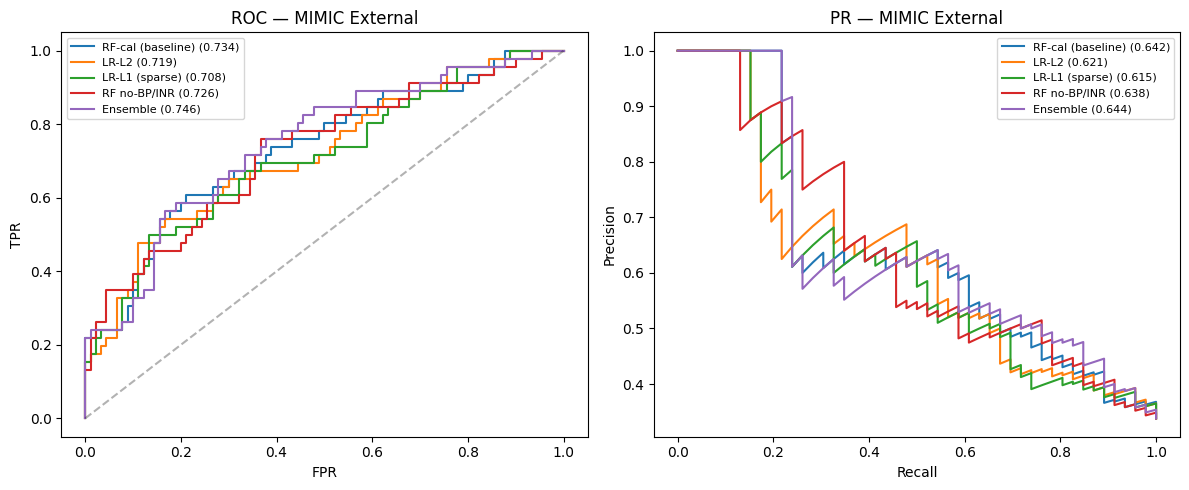

In [ ]:
rows = [
    ('RF calibrated (baseline)',  ref_val['auc'],       ref_mimic['auc'],       ref_mimic['pr'],       ref_mimic['sens'],       ref_mimic['spec']),
    ('LR-L2  (C=0.1)',            lr_l2_val_res['auc'], lr_l2_mimic_res['auc'], lr_l2_mimic_res['pr'], lr_l2_mimic_res['sens'], lr_l2_mimic_res['spec']),
    ('LR-L1  (sparse)',           lr_l1_val_res['auc'], lr_l1_mimic_res['auc'], lr_l1_mimic_res['pr'], lr_l1_mimic_res['sens'], lr_l1_mimic_res['spec']),
    ('RF selective (no BP/INR)',   sel_val_res['auc'],   sel_mimic_res['auc'],   sel_mimic_res['pr'],   sel_mimic_res['sens'],   sel_mimic_res['spec']),
    ('Ensemble RF-cal + LR-L1',   ens_val_res['auc'],   ens_mimic_res['auc'],   ens_mimic_res['pr'],   ens_mimic_res['sens'],   ens_mimic_res['spec']),
]
cols = ['Method', 'Val AUC', 'MIMIC AUC', 'MIMIC PR', 'MIMIC Sens', 'MIMIC Spec']
df_cmp = pd.DataFrame(rows, columns=cols).set_index('Method')
print(df_cmp.round(3).to_string())

# ROC curves on MIMIC
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, title, pairs in zip(axes,
    ['ROC — MIMIC External', 'PR — MIMIC External'],
    [
        [(y_mimic, p_rf_mimic_ls,   'RF-cal (baseline)'),
         (y_mimic, p_lr_l2_mimic_ls,'LR-L2'),
         (y_mimic, p_lr_l1_mimic_ls,'LR-L1 (sparse)'),
         (y_mimic, p_sel_mimic_ls,  'RF no-BP/INR'),
         (y_mimic, p_ens_mimic_ls,  'Ensemble')],
        [(y_mimic, p_rf_mimic_ls,   'RF-cal (baseline)'),
         (y_mimic, p_lr_l2_mimic_ls,'LR-L2'),
         (y_mimic, p_lr_l1_mimic_ls,'LR-L1 (sparse)'),
         (y_mimic, p_sel_mimic_ls,  'RF no-BP/INR'),
         (y_mimic, p_ens_mimic_ls,  'Ensemble')],
    ]):
    for y, p, lbl in pairs:
        if 'ROC' in title:
            fpr, tpr, _ = roc_curve(y, p)
            ax.plot(fpr, tpr, label=f'{lbl} ({roc_auc_score(y,p):.3f})')
        else:
            prec, rec, _ = precision_recall_curve(y, p)
            ax.plot(rec, prec, label=f'{lbl} ({average_precision_score(y,p):.3f})')
    if 'ROC' in title:
        ax.plot([0,1],[0,1],'k--', alpha=0.3)
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    else:
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
    ax.set_title(title); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f'/content/drive/MyDrive/AI in Medicine/documents/extended_baselines_roc_pr.png', dpi=150)
plt.show()

## 6. Save

In [ ]:
with open(f'{EXT8_DIR}/lr_l2_80.pkl', 'wb') as f: pickle.dump(lr_l2, f)
with open(f'{EXT8_DIR}/lr_l1_80.pkl', 'wb') as f: pickle.dump(lr_l1, f)
with open(f'{EXT8_DIR}/rf_selective_80.pkl', 'wb') as f: pickle.dump(rf_sel_cal, f)

ext8_results = {
    'bp_inr_dropped': bp_inr_cols,
    'lr_l1_nonzero_features': n_nonzero,
    'lr_l2':        {k: float(v) for k,v in lr_l2_mimic_res.items()},
    'lr_l1':        {k: float(v) for k,v in lr_l1_mimic_res.items()},
    'rf_selective': {k: float(v) for k,v in sel_mimic_res.items()},
    'ensemble':     {k: float(v) for k,v in ens_mimic_res.items()},
    'val': {
        'lr_l2_thr': float(lr_l2_val_thr),
        'lr_l1_thr': float(lr_l1_val_thr),
        'sel_thr':   float(sel_val_thr),
        'ens_thr':   float(ens_val_thr),
    }
}
with open(f'{EXT8_DIR}/extended_results_80.json', 'w') as f:
    json.dump(ext8_results, f, indent=2)

print('Saved to models/extended_80/')
print(json.dumps(ext8_results, indent=2))

Saved to models/extended_80/
{
  "bp_inr_dropped": [
    "dbp_max",
    "dbp_mean",
    "dbp_min",
    "inr_max",
    "inr_min",
    "map_max",
    "map_mean",
    "map_min",
    "sbp_mean",
    "sbp_min"
  ],
  "lr_l1_nonzero_features": 43,
  "lr_l2": {
    "auc": 0.7190821256038648,
    "pr": 0.621361938530439,
    "sens": 0.4782608695652174,
    "spec": 0.8444444444444444
  },
  "lr_l1": {
    "auc": 0.7077294685990339,
    "pr": 0.6152795140326421,
    "sens": 0.7391304347826086,
    "spec": 0.4777777777777778
  },
  "rf_selective": {
    "auc": 0.7256038647342996,
    "pr": 0.6376909909834637,
    "sens": 0.45652173913043476,
    "spec": 0.8222222222222222
  },
  "ensemble": {
    "auc": 0.7463768115942029,
    "pr": 0.6440629802592952,
    "sens": 0.5217391304347826,
    "spec": 0.8444444444444444
  },
  "val": {
    "lr_l2_thr": 0.6630713574442257,
    "lr_l1_thr": 0.33574681574927756,
    "sel_thr": 0.04435140710654878,
    "ens_thr": 0.17704422303499395
  }
}
